### Imports

In [1]:
from pathlib import Path
from typing import Any

import numpy as np

from equity_pricing.calibration import calibrate_smile, calibrate_surface
from equity_pricing.heston import model_surface, price_european
from equity_pricing.plots import plot_residual_heatmap, plot_smile_fit, plot_volatility_surface
from equity_pricing.simulation import price_vanilla_mc
from equity_pricing.types import (
    CalibrationSettings,
    FlatMarketInputs,
    HestonParams,
    OptionSide,
    VanillaOption,
)

### Inputs

In [ ]:
market = FlatMarketInputs(spot=100.0, risk_free_rate=0.02, dividend_yield=0.01)
true_params = HestonParams(kappa=2.0, theta=0.04, sigma=0.2, rho=-0.3, v0=0.04)
initial_params = HestonParams(kappa=1.4, theta=0.05, sigma=0.35, rho=-0.15, v0=0.05)

maturities = np.array([0.5, 1.0], dtype=float)
strikes_by_expiry = (
    np.array([90.0, 100.0, 110.0], dtype=float),
    np.array([85.0, 100.0, 115.0], dtype=float),
)


### Run

#### Calibrate Equity Vol Surface

In [3]:
# Mock Synthetic surface
synthetic_surface = model_surface(
    strikes_by_expiry,
    maturities,
    market,
    true_params,
    upper_limit=120.0,
    abs_tol=1.0e-7,
    rel_tol=1.0e-7,
)

In [4]:
print(synthetic_surface)

MarketSurface(smiles=(MarketSmile(quotes=(SmileQuote(strike=90.0, maturity=0.5, implied_vol=0.20439499888484378), SmileQuote(strike=100.0, maturity=0.5, implied_vol=0.19764114170386235), SmileQuote(strike=110.0, maturity=0.5, implied_vol=0.1931231739065446))), MarketSmile(quotes=(SmileQuote(strike=85.0, maturity=1.0, implied_vol=0.20527847948153766), SmileQuote(strike=100.0, maturity=1.0, implied_vol=0.1971976657051822), SmileQuote(strike=115.0, maturity=1.0, implied_vol=0.1922033331488486)))))


In [5]:
calibration_settings = CalibrationSettings(
    upper_limit=120.0,
    abs_tol=1.0e-7,
    rel_tol=1.0e-7,
    integration_limit=150,
    n_restarts=2,
)


In [6]:
surface_result = calibrate_surface(
    synthetic_surface,
    market,
    initial_params,
    calibration_settings,
)

smile_result = calibrate_smile(
    synthetic_surface.smiles[0],
    market,
    initial_params,
    calibration_settings,
)


## Price Vanilla Option

In [7]:
option = VanillaOption(strike=100.0, maturity=1.0, side=OptionSide.CALL)

In [8]:
# Analytic Price with Heston 
analytic_price = price_european(
        option,
        market,
        surface_result.params,
        upper_limit=120.0,
        abs_tol=1.0e-7,
        rel_tol=1.0e-7,
        limit=150,
    )
print(analytic_price)

8.239953742246826


In [9]:
mc_result = price_vanilla_mc(
        option,
        market,
        surface_result.params,
        steps=32,
        n_paths=4_000,
        seed=1234,
    )
print(mc_result.price)

8.475440147315956


## Plot Vol Surface Fit

### Smile

C:\Users\tania\AppData\Local\Temp\ipykernel_13132\2271179482.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  smile_figure.show()


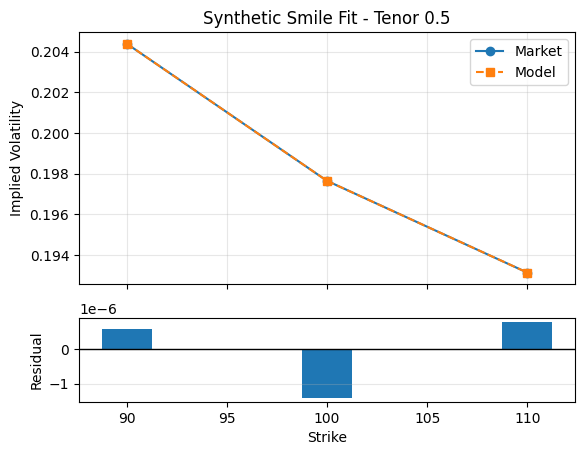

In [13]:
smile_figure, _ = plot_smile_fit(
    synthetic_surface.smiles[0],
    smile_result,
    title=f"Synthetic Smile Fit - Tenor {synthetic_surface.maturities[0]}",
)

smile_figure.show()

### Surface

C:\Users\tania\AppData\Local\Temp\ipykernel_13132\3728358094.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  surface_figure.show()


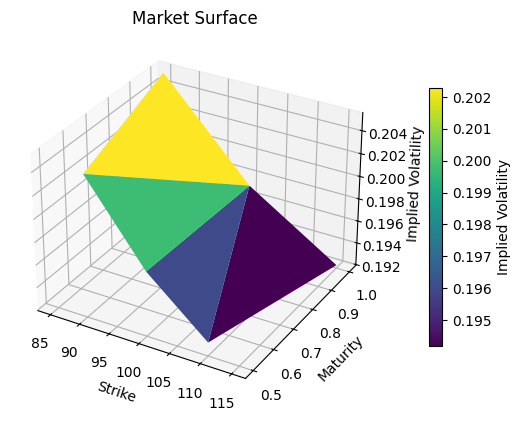

In [11]:
surface_figure, _= plot_volatility_surface(synthetic_surface, title="Market Surface")
surface_figure.show()

C:\Users\tania\AppData\Local\Temp\ipykernel_30568\3189797723.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  heatmap_figure.show()


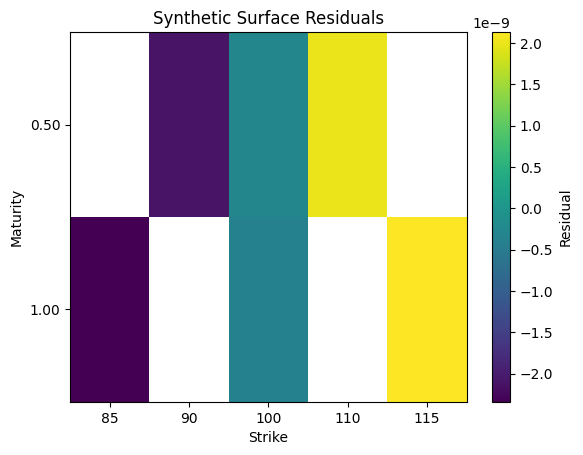

In [16]:
heatmap_figure, _ = plot_residual_heatmap(
        synthetic_surface,
        surface_result,
        title="Synthetic Surface Residuals",
    )

heatmap_figure.show()